In [1]:
#STEP 1: Load & Understand Data
import pandas as pd

df= pd.read_csv('titanic.csv')

print('shape: \n',df.shape)
print('info: \n',df.info())
print('describe: \n',df.describe())
print('top 5: \n',df.head())

shape: 
 (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
info: 
 None
describe: 
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std  

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
age hist: 
outlier: 
value count: 
Sex
male      577
female    314
Name: count, dtype: int64


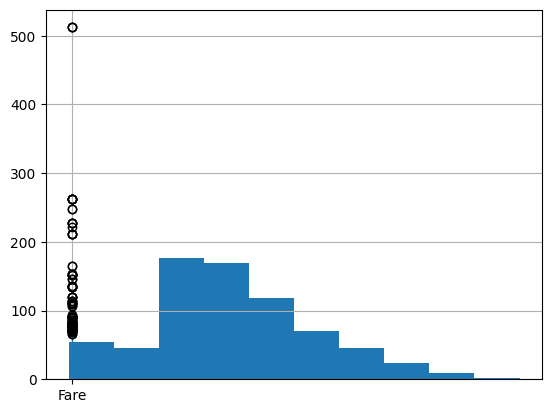

In [ ]:
#STEP 2: Quick EDA (VERY IMPORTANT)
# Missing values
print(df.isnull().sum())

# Distribution
print('age hist: ')
df['Age'].hist()

# Outliers
print('outlier: ')
df.boxplot(column='Fare')

# Category counts
print('value count: ')
print(df['Sex'].value_counts())

In [ ]:
# STEP 3: Data Cleaning
# Fill missing values (direct assignment — avoids ChainedAssignmentError in pandas 2.0+)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop useless columns (PassengerId is a meaningless identifier, not a feature)
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [ ]:
#STEP 4: Encoding
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [ ]:
#STEP 5: Split Data
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#STEP 6: Train Multiple Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

In [ ]:
#STEP 7: Evaluate Models
from sklearn.metrics import accuracy_score

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

print("Logistic:", accuracy_score(y_test, lr_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))

In [ ]:
#STEP 8: Cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("CV Score:", scores.mean())

In [ ]:
#STEP 9: Understand Results
from sklearn.metrics import classification_report, confusion_matrix

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

# Feature importance from Random Forest
import pandas as pd
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop Features:\n", feat_imp)

In [ ]:
#STEP 10: Improve Model
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test Score:", grid.score(X_test, y_test))